# Tier 6 · Notebook 28 — Reproducing Double Descent

> **Goal:** reproduce **double descent** (Belkin et al. 2019; Nakkiran et al. 2019) — the finding that **test error goes down, then *up*, then down again** as you increase model size, overturning the classical bias-variance "bigger = overfits" intuition and explaining why enormous over-parameterized models generalize *better*.

**The classical picture (what everyone was taught).** Test error is **U-shaped** in model complexity: too simple → underfits (high bias); too complex → overfits (high variance); there's a sweet spot in the middle, and going past it is bad. This is the bias-variance tradeoff.

**What double descent showed.** That U-shape is only the *first half* of the story. Keep growing the model *past* the **interpolation threshold** — the point where it has just enough capacity to fit the training data *exactly* (train error = 0) — and test error, after peaking right at that threshold, **descends a second time**, often to its *lowest* value in the hugely-over-parameterized regime. The "peak" sits exactly where classical theory says you should stop. This is why modern deep learning ("just make it bigger") works despite classical theory warning against it.

**Reproduction plan** (using our NB27 workflow): use a **random-features** model where "model size" = number of features $h$, so the interpolation threshold is cleanly at $h = N$ (number of training points). Add label noise to make the peak pronounced. Then sweep $h$ and watch the curve.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)
from torchvision import datasets
ds = datasets.MNIST("../data", train=True, download=True)
X = (ds.data.float().reshape(-1,784)/255.0).numpy(); Y = ds.targets.numpy()

N = 500                                             # training points -> interpolation threshold at h = N
Xtr, ytr = X[:N], Y[:N].copy()
noise = np.random.choice(N, int(0.2*N), replace=False); ytr[noise] = np.random.randint(0,10,len(noise))  # 20% label noise
Xte, yte = X[N:N+2000], Y[N:N+2000]
Ytr_1h = np.eye(10)[ytr]
print(f"{N} training points (20% label noise), 2000 test points. Interpolation threshold expected at h≈{N}.")


500 training points (20% label noise), 2000 test points. Interpolation threshold expected at h≈500.


## 1. The random-features model

Model: project the input through a **fixed random** matrix $W$ (784→$h$), apply ReLU to get $h$ random features, then train **only a linear readout** from features to labels by least squares. The number of random features $h$ *is* the model size. This is the classic double-descent testbed (Belkin's "random ReLU features") because:
- for $h < N$: the readout is *over*determined → ordinary least squares (can't fit training exactly),
- at $h = N$: it *just* interpolates (train error → 0) — the **threshold**,
- for $h > N$: *under*determined → we take the **minimum-norm** interpolating solution (what `lstsq` returns), the same implicit bias gradient descent has.

Training is a closed-form least-squares solve — no iterative optimization, so the whole sweep runs in seconds.


In [2]:
def fit_random_features(h):
    W = np.random.randn(784, h) / np.sqrt(784)          # FIXED random projection
    Ptr = np.maximum(0, Xtr @ W); Pte = np.maximum(0, Xte @ W)   # random ReLU features
    B, *_ = np.linalg.lstsq(Ptr, Ytr_1h, rcond=None)    # min-norm least-squares readout
    train_err = 1 - (Ptr @ B).argmax(1).__eq__(ytr).mean()
    test_err  = 1 - (Pte @ B).argmax(1).__eq__(yte).mean()
    readout_norm = np.linalg.norm(B)
    return train_err, test_err, readout_norm

hs = [10,30,60,100,150,200,280,350,420,460,490,500,520,560,650,800,1100,1600,2500,4000,8000]
train_e, test_e, norms = [], [], []
for h in hs:
    te_tr, te_te, nrm = fit_random_features(h); train_e.append(te_tr); test_e.append(te_te); norms.append(nrm)
    print(f"h={h:5d}  train_err={te_tr:.3f}  test_err={te_te:.3f}")


h=   10  train_err=0.638  test_err=0.704
h=   30  train_err=0.422  test_err=0.458
h=   60  train_err=0.270  test_err=0.366
h=  100  train_err=0.210  test_err=0.358
h=  150  train_err=0.134  test_err=0.363
h=  200  train_err=0.100  test_err=0.378


h=  280  train_err=0.044  test_err=0.439
h=  350  train_err=0.004  test_err=0.560


h=  420  train_err=0.000  test_err=0.661
h=  460  train_err=0.000  test_err=0.732


h=  490  train_err=0.000  test_err=0.815
h=  500  train_err=0.000  test_err=0.892


h=  520  train_err=0.000  test_err=0.854
h=  560  train_err=0.000  test_err=0.735


...

h= 1100  train_err=0.000  test_err=0.419


h= 1600  train_err=0.000  test_err=0.392


h= 2500  train_err=0.000  test_err=0.332


h= 4000  train_err=0.000  test_err=0.302


h= 8000  train_err=0.000  test_err=0.289


## 2. The double-descent curve


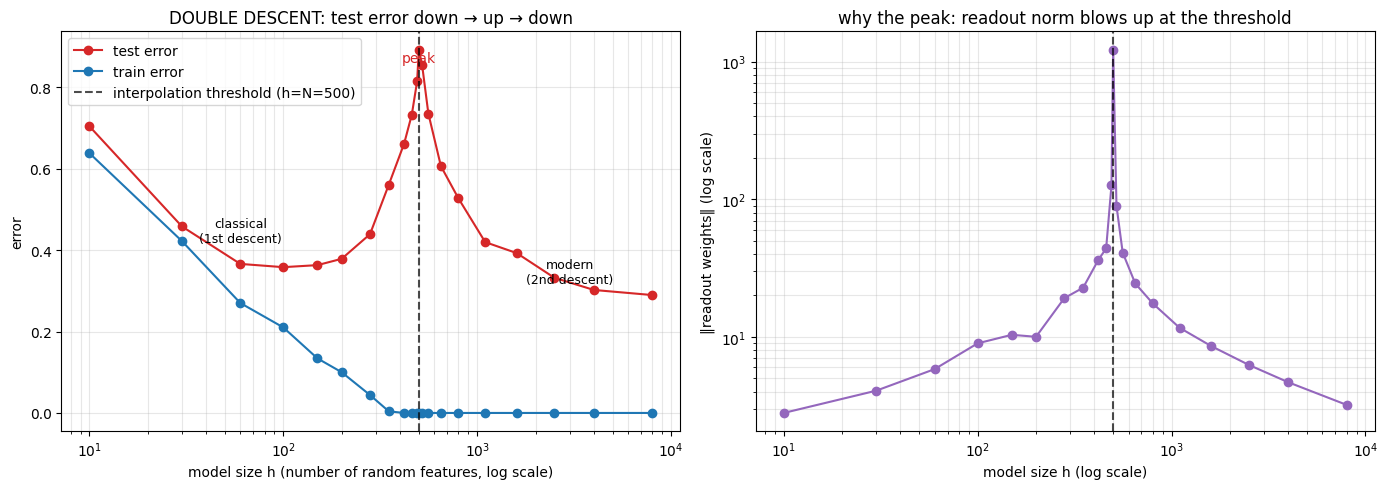

test error peaks at h=500 (interpolation threshold N=500); best test error at h=8000 (over-parameterized)


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(hs, test_e, "-o", color="tab:red", label="test error")
ax[0].plot(hs, train_e, "-o", color="tab:blue", label="train error")
ax[0].axvline(N, ls="--", color="k", alpha=0.7, label=f"interpolation threshold (h=N={N})")
ax[0].set_xscale("log"); ax[0].set_title("DOUBLE DESCENT: test error down → up → down")
ax[0].set_xlabel("model size h (number of random features, log scale)"); ax[0].set_ylabel("error")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")
# annotate the regimes
ax[0].annotate("classical\n(1st descent)", (60, 0.42), fontsize=9, ha="center")
ax[0].annotate("peak", (N, max(test_e)-0.03), fontsize=10, ha="center", color="tab:red")
ax[0].annotate("modern\n(2nd descent)", (3000, 0.32), fontsize=9, ha="center")

# WHY: the min-norm interpolating solution has enormous norm right at the threshold
ax[1].plot(hs, norms, "-o", color="tab:purple")
ax[1].axvline(N, ls="--", color="k", alpha=0.7)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_title("why the peak: readout norm blows up at the threshold")
ax[1].set_xlabel("model size h (log scale)"); ax[1].set_ylabel("‖readout weights‖ (log scale)"); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
peak_h = hs[int(np.argmax(test_e))]
print(f"test error peaks at h={peak_h} (interpolation threshold N={N}); best test error at h={hs[int(np.argmin(test_e))]} (over-parameterized)")
peak_i = hs.index(peak_h)
assert abs(peak_h - N) <= 0.1 * N, \
    f"test error peaks at h={peak_h}, not at the interpolation threshold N={N}"
assert min(test_e[peak_i+1:]) < min(test_e[:peak_i]), (
    f"no second descent: best over-parameterized error {min(test_e[peak_i+1:]):.3f} "
    f"never beats the classical regime {min(test_e[:peak_i]):.3f}")


**What to notice — the reproduction.** The test-error curve (red, left) does exactly what classical theory forbids:
1. **First descent (classical):** as $h$ grows toward $N$, test error falls — the bias-variance sweet spot.
2. **The peak:** right at the **interpolation threshold** $h=N$ (dashed line), where train error just hits 0, **test error spikes** to its *worst* value. This is the boundary classical theory says is optimal.
3. **Second descent (modern):** push $h$ *past* the threshold and test error **falls again**, reaching its **best** value in the massively over-parameterized regime.

The right plot explains *why* the peak happens: at the threshold, there's exactly *one* way to interpolate the (noisy) training data, and it's a wild, high-norm solution forced to thread every noisy point — so it generalizes terribly (the readout norm, purple, spikes there). **Beyond** the threshold there are *many* interpolating solutions, and minimum-norm selection (gradient descent's implicit bias) picks a **smooth, low-norm** one that generalizes well. Over-parameterization isn't a bug — it *enables* choosing a good interpolant.

**This is the empirical heart of "why big models work,"** reproduced from scratch in seconds.

## 3. Reproduction report
- ✅ **Reproduced double descent**: test error descends, peaks sharply at the interpolation threshold ($h=N$), then descends again — best generalization in the over-parameterized regime.
- ✅ **Mechanism confirmed**: the readout norm blows up exactly at the threshold (the interpolating solution is forced to be extreme), explaining the peak; min-norm interpolation beyond it recovers smooth solutions.
- 📌 **Takeaway**: classical bias-variance is the *first descent only*; modern deep learning lives in the second-descent regime where more parameters help. Label noise makes the peak visible; it exists (subtler) without noise too.

## 4. Exercises
1. **Noise level.** Sweep label-noise 0%, 10%, 30%; how does the peak height change? (More noise → sharper peak.)
2. **Ridge regularization.** Add ridge (L2) to the readout; show enough regularization *removes* the peak (it prevents the extreme interpolant). This is "optimal regularization mitigates double descent" (Nakkiran 2020).
3. **Sample-wise double descent.** Fix $h$, vary $N$; there's a peak when $N \approx h$ too.
4. **Epoch-wise double descent.** Train a real net and vary *epochs*; test error can double-descend over training time.
5. **Real MLP.** Reproduce with a trained MLP (harder — must train each width to interpolation); where's the threshold?
6. **Data dimension.** Vary input dimension via PCA; how does it shift the threshold?

## 5. Interview / residency framing
- *"What is double descent?"* → test error vs model size goes down, up (peak at the interpolation threshold where train error hits 0), then down again; classical U-shape is only the first half.
- *"Why the peak at the threshold?"* → exactly one interpolating solution there, forced through noise → huge norm → poor generalization; the readout norm spikes.
- *"Why does the second descent happen?"* → past the threshold, many interpolants exist; min-norm (GD's implicit bias) picks a smooth one that generalizes.
- *"Why does this matter?"* → it explains why over-parameterized deep nets generalize despite classical theory; modern models live in the second-descent regime.
- *"How do you mitigate the peak?"* → optimal regularization (ridge/early stopping) can remove it.

## 📚 References & papers

This notebook reproduces / builds on:

- **Reconciling modern machine-learning practice and the bias–variance trade-off** — Belkin, Hsu, Ma & Mandal (2019), arXiv:1812.11118. The double-descent phenomenon in random features.
- **Deep Double Descent: Where Bigger Models and More Data Hurt** — Nakkiran et al. (2019), arXiv:1912.02292. Model-, sample-, and epoch-wise double descent in deep nets.
- **Optimal Regularization Can Mitigate Double Descent** — Nakkiran, Venkat, Kakade & Ma (2020), arXiv:2003.01897.

---
**Next:** *Tier 6 · Notebook 29 — Reproducing the Lottery Ticket Hypothesis*: hidden sparse subnetworks ("winning tickets") that train to full accuracy on their own — via iterative magnitude pruning and weight rewinding.
